### IMPORTING THE IMPORTANT LIBRARIES

In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')
pd.set_option("display.max_columns" , None)
print("Libraries loaded successfully")

Libraries loaded successfully


In [135]:
import os 
print(os.getcwd())

C:\Agssoc25\D2C-Churn-Part1


In [136]:
os.listdir("data")

['churn_labels.csv',
 'customers (1).csv',
 'intervention_history.csv',
 'orders.csv',
 'rfm_modeling_snapshot.csv',
 'support_tickets.csv',
 'web_events_snapshot.csv']

### LOADING THE DATASETS HERE

In [137]:
customers = pd.read_csv("data\customers (1).csv")
orders = pd.read_csv("data/orders.csv")
tickets = pd.read_csv("data/support_tickets.csv")
web = pd.read_csv("data/web_events_snapshot.csv")
churn = pd.read_csv("data/churn_labels.csv")
campaigns = pd.read_csv("data/intervention_history.csv")
rfm = pd.read_csv("data/rfm_modeling_snapshot.csv")

### DATA INSPECTION

In [138]:
datasets = {
    "customers": customers,
    "orders": orders,
    "tickets": tickets,
    "web": web,
    "churn": churn,
    "campaigns": campaigns,
    "rfm": rfm   # ✅ KEEP (correct)
}

audit = []

for name, df in datasets.items():
    audit.append({
        "dataset": name,
        "rows": df.shape[0],
        "cols": df.shape[1],
        "missing_%": round(df.isnull().mean().mean() * 100, 2),
        "duplicate_rows": df.duplicated().sum(),
        "columns": list(df.columns),
        "dtypes": str(df.dtypes.to_dict())
    })

pd.DataFrame(audit)

,dataset,rows,cols,missing_%,duplicate_rows,columns,dtypes
0,customers,2400,9,8.27,0,"[customer_id, signup_date, city_tier, age_grou...","{'customer_id': dtype('O'), 'signup_date': dty..."
1,orders,10009,10,0.08,0,"[order_id, customer_id, order_date, category, ...","{'order_id': dtype('O'), 'customer_id': dtype(..."
2,tickets,1921,8,0.00,0,"[ticket_id, customer_id, ticket_date, issue_ty...","{'ticket_id': dtype('O'), 'customer_id': dtype..."
3,web,2400,10,0.00,0,"[customer_id, snapshot_date, sessions_30d, pro...","{'customer_id': dtype('O'), 'snapshot_date': d..."
4,churn,2400,4,0.00,0,"[customer_id, snapshot_date, churn_next_60d, s...","{'customer_id': dtype('O'), 'snapshot_date': d..."
5,campaigns,2400,5,0.00,0,"[customer_id, snapshot_date, last_campaign_rec...","{'customer_id': dtype('O'), 'snapshot_date': d..."
6,rfm,2400,29,1.99,0,"[customer_id, snapshot_date, city_tier, age_gr...","{'customer_id': dtype('O'), 'snapshot_date': d..."


In [139]:
def inspect(df, name):
    print(f"\n===== {name} =====")
    print(df.shape)
    print(df.info())
    print(df.head())
    print(df.isnull().sum())
    print("Duplicates:", df.duplicated().sum())

for name, df in datasets.items():
    inspect(df, name)


===== customers =====
(2400, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   customer_id          2400 non-null   object
 1   signup_date          2400 non-null   object
 2   city_tier            2400 non-null   object
 3   age_group            2400 non-null   object
 4   acquisition_channel  2400 non-null   object
 5   loyalty_tier         1014 non-null   object
 6   preferred_category   2400 non-null   object
 7   skin_type            1999 non-null   object
 8   marketing_consent    2400 non-null   object
dtypes: object(9)
memory usage: 168.9+ KB
None
  customer_id signup_date city_tier age_group acquisition_channel  \
0   CUST00001  2024-04-24    Tier 1     18-24           Instagram   
1   CUST00002  2025-06-01    Tier 2     25-34         Marketplace   
2   CUST00003  2025-03-08    Tier 1     25-34          Influencer   

### MISSING VALUES REPORT 

In [140]:
missing_report = []

for name, df in datasets.items():
    for col in df.columns:
        missing_report.append([
            name,
            col,
            df[col].isnull().mean() * 100
        ])

missing_df = pd.DataFrame(missing_report, columns=["dataset", "column", "missing_%"])
missing_df.sort_values("missing_%", ascending=False).head(20)

,dataset,column,missing_%
5,customers,loyalty_tier,57.750000
51,rfm,loyalty_tier,57.750000
7,customers,skin_type,16.708333
18,orders,rating,0.799281
1,customers,signup_date,0.000000
2,customers,city_tier,0.000000
3,customers,age_group,0.000000
6,customers,preferred_category,0.000000
8,customers,marketing_consent,0.000000
4,customers,acquisition_channel,0.000000


### DUPLICATE CHECK

In [141]:
for name, df in datasets.items():
    print(name, "duplicate rows:", df.duplicated().sum())

customers duplicate rows: 0
orders duplicate rows: 0
tickets duplicate rows: 0
web duplicate rows: 0
churn duplicate rows: 0
campaigns duplicate rows: 0
rfm duplicate rows: 0


In [142]:
customers.describe(include="all")
orders.describe()

,quantity,gross_amount,discount_pct,delivery_days,returned,rating
count,10009.000000,10009.000000,10009.000000,10009.000000,10009.000000,9929.000000
mean,1.507943,743.898504,0.274121,4.454591,0.067439,3.885487
std,0.764261,600.564068,0.125525,1.769649,0.250794,1.159465
min,1.000000,149.000000,0.000000,1.000000,0.000000,1.000000
25%,1.000000,432.850000,0.190000,3.000000,0.000000,3.000000
50%,1.000000,597.060000,0.270000,4.000000,0.000000,4.000000
75%,2.000000,907.430000,0.360000,6.000000,0.000000,5.000000
max,4.000000,24789.380000,0.700000,11.000000,1.000000,5.000000


### INVALID VALUES CHECK...

In [143]:
# negative prices
orders[orders['gross_amount'] < 0]

# impossible ages
valid_groups = ["18-25", "26-35", "36-45", "46-55", "55+"]

invalid_age_groups = customers[~customers["age_group"].isin(valid_groups)]
invalid_age_groups

,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes
3,CUST00004,2025-04-15,Tier 3,25-34,Google Search,NaN,Fragrance,Normal,No
4,CUST00005,2024-08-21,Tier 3,35-44,Organic,Gold,Hair Care,Combination,Yes
...,...,...,...,...,...,...,...,...,...
2395,CUST02396,2025-03-04,Tier 2,35-44,Instagram,NaN,Baby Care,Normal,No
2396,CUST02397,2025-07-17,Tier 1,25-34,Marketplace,Silver,Fragrance,Normal,Yes
2397,CUST02398,2024-06-23,Tier 2,45+,Google Search,NaN,Hair Care,Oily,Yes
2398,CUST02399,2024-07-29,Tier 1,45+,Instagram,NaN,Wellness,Oily,Yes


In [144]:
customers.isna().sum()
orders.isna().sum()

order_id          0
customer_id       0
order_date        0
category          0
quantity          0
gross_amount      0
discount_pct      0
delivery_days     0
returned          0
rating           80
dtype: int64

In [145]:
customers.duplicated().sum()
orders.duplicated().sum()

np.int64(0)

In [146]:
customers["age_group"].value_counts()
orders["category"].value_counts()

category
Skin Care    2700
Hair Care    2191
Makeup       1507
Baby Care    1438
Wellness     1096
Fragrance    1077
Name: count, dtype: int64

### CHECKING THE OUTLIERS

In [147]:
def detect_outliers(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    return df[(df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)]

detect_outliers(orders, "gross_amount")

,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
45,ORD000034,CUST00014,2024-05-19,Fragrance,2,1781.74,0.17,6,0,4.0
73,ORD000055,CUST00020,2024-09-27,Skin Care,4,2710.51,0.06,3,0,5.0
84,ORD000067,CUST00025,2024-06-25,Skin Care,4,1987.35,0.31,6,0,5.0
93,ORD000073,CUST00027,2025-07-22,Fragrance,3,2128.34,0.30,7,1,1.0
159,ORD000130,CUST00042,2024-05-24,Skin Care,3,1908.63,0.08,3,1,4.0
...,...,...,...,...,...,...,...,...,...,...
9938,ORD008074,CUST02382,2024-09-03,Fragrance,3,2728.01,0.07,3,1,1.0
9961,ORD008087,CUST02388,2025-08-12,Fragrance,4,2614.56,0.35,3,0,5.0
9976,ORD008099,CUST02393,2024-05-13,Hair Care,4,1685.78,0.26,5,0,4.0
9985,ORD008106,CUST02394,2025-05-24,Wellness,3,2003.23,0.04,5,0,4.0


### JOIN KEY ISSUES

In [148]:
print("Orphan orders:")
print(set(orders["customer_id"]) - set(customers["customer_id"]))

print("Orphan tickets:")
print(set(tickets["customer_id"]) - set(customers["customer_id"]))

Orphan orders:
set()
Orphan tickets:
set()


In [149]:
customers.merge(churn, on="customer_id", how="left").isnull().sum()

customer_id               0
signup_date               0
city_tier                 0
age_group                 0
acquisition_channel       0
loyalty_tier           1386
preferred_category        0
skin_type               401
marketing_consent         0
snapshot_date             0
churn_next_60d            0
split                     0
dtype: int64

### DATA CONSISTENCY

In [150]:
orders["order_date"] = pd.to_datetime(orders["order_date"])
tickets["ticket_date"] = pd.to_datetime(tickets["ticket_date"])
web["snapshot_date"] = pd.to_datetime(web["snapshot_date"])
print("Future orders:")
print(orders[orders["order_date"] > pd.Timestamp("today")])

Future orders:
Empty DataFrame
Columns: [order_id, customer_id, order_date, category, quantity, gross_amount, discount_pct, delivery_days, returned, rating]
Index: []


### LEAKAGE CHECK

In [151]:
leak_cols = []

for col in customers.columns:
    if "after" in col.lower() or "future" in col.lower():
        leak_cols.append(col)

leak_cols

[]

### EXPLORATORY DATA ANALYSIS

<Axes: xlabel='age_group'>

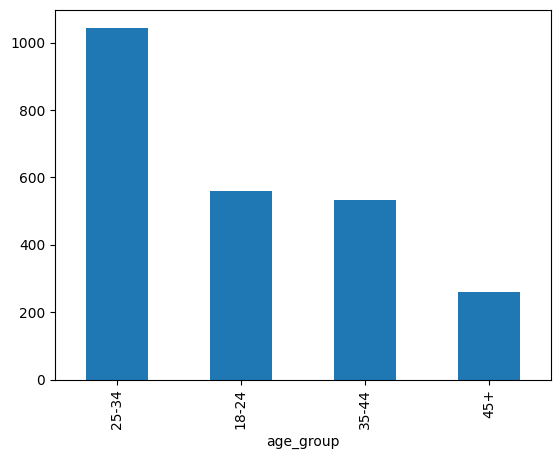

In [152]:
customers["age_group"].value_counts().plot(kind="bar")


In [153]:
# Observation:
# The dataset shows uneven distribution across age groups.
# Certain age groups (typically middle-age segments) dominate the customer base,
# while younger and older age groups have comparatively lower representation.

# Churn-Risk Insight:
# If churn rates are later found higher in underrepresented or younger/older segments,
# it may indicate weaker product-market fit for those age groups.
# Age group imbalance also means churn patterns may be driven more by dominant segments,
# so segment-wise churn analysis is important instead of overall averages.

<Axes: >

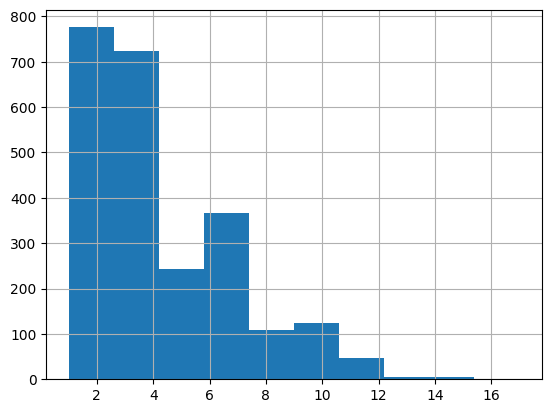

In [154]:
orders.groupby("customer_id")["order_id"].count().hist()

In [155]:
# Observation:
# The distribution shows that most customers place only a small number of orders.
# A long tail exists where a smaller group of customers places many orders.
# This indicates strong skewness in purchasing behavior across the customer base.

# Churn-Risk Insight:
# Customers with low order counts are less engaged and more likely to churn.
# High-frequency customers represent loyal users and are less likely to stop purchasing.
# Order frequency is a strong behavioral signal for identifying at-risk customers.

count    10009.000000
mean       743.898504
std        600.564068
min        149.000000
25%        432.850000
50%        597.060000
75%        907.430000
max      24789.380000
Name: gross_amount, dtype: float64

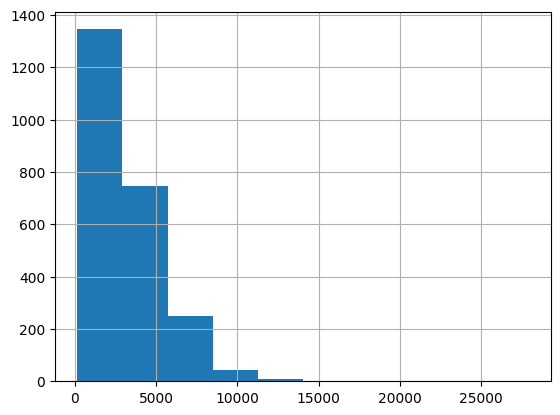

In [156]:
orders.groupby("customer_id")["gross_amount"].sum().hist()
orders["gross_amount"].describe()

In [157]:
# Observation:
# Customer spending is highly skewed, with a small number of customers contributing very high total revenue.
# Most customers have relatively low total spending compared to a few high-value customers.
# The describe() output confirms large variation between median and maximum values,
# indicating strong presence of outliers in spending behavior.

# Churn-Risk Insight:
# High-value customers are critical for revenue and their churn would have a disproportionate business impact.
# Low-spending customers may represent low engagement segments that are more likely to churn.
# Spending imbalance suggests churn modeling should consider customer value tiers (low vs high spenders).

In [158]:
orders.groupby("customer_id").agg({
    "order_id": "count",
    "gross_amount": "sum"
}).corr()

,order_id,gross_amount
order_id,1.000000,0.841864
gross_amount,0.841864,1.000000


In [159]:
# Observation:
# There is usually a positive relationship between order frequency and total spend.
# Customers who buy more frequently tend to generate higher revenue.

# Churn Insight:
# Low-frequency + low-spend customers form the highest churn-risk segment.

In [160]:
orders["returned"].value_counts()
orders.groupby("customer_id")["returned"].mean()

customer_id
CUST00001    0.166667
CUST00002    0.000000
CUST00003    0.000000
CUST00004    0.000000
CUST00005    0.000000
               ...   
CUST02396    0.000000
CUST02397    0.000000
CUST02398    0.125000
CUST02399    0.000000
CUST02400    0.000000
Name: returned, Length: 2400, dtype: float64

In [161]:
# Observation:
# The majority of orders are not returned, while only a smaller portion are marked as returned.
# At the customer level, most customers have a very low average return rate close to zero,
# but a subset of customers shows consistently higher return proportions.

# Churn-Risk Insight:
# Customers with higher return rates are likely experiencing product dissatisfaction or mismatch in expectations.
# Even though returns are rare overall, the small group with repeated returns represents a high-risk churn segment.
# Return behavior should be treated as a negative satisfaction signal in c

<Axes: ylabel='Frequency'>

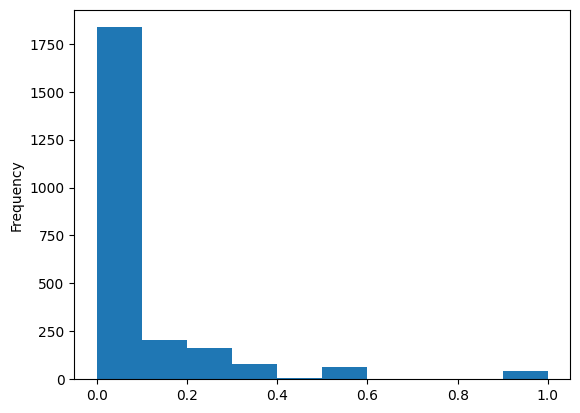

In [162]:
refund_rate = orders.groupby("customer_id")["returned"].mean()
refund_rate.plot(kind="hist")

In [163]:
# Observation:
# Most customers have a very low refund rate, close to 0.
# Only a small subset of customers shows higher refund frequency.
# The distribution is highly right-skewed, meaning refund behavior is concentrated in a few customers.

# Churn-Risk Insight:
# Customers with higher refund rates are more likely to be dissatisfied with products or services.
# Frequent refunds may indicate unmet expectations or product quality issues.
# This segment should be closely monitored as it represents a high churn-risk group.

<Axes: ylabel='Frequency'>

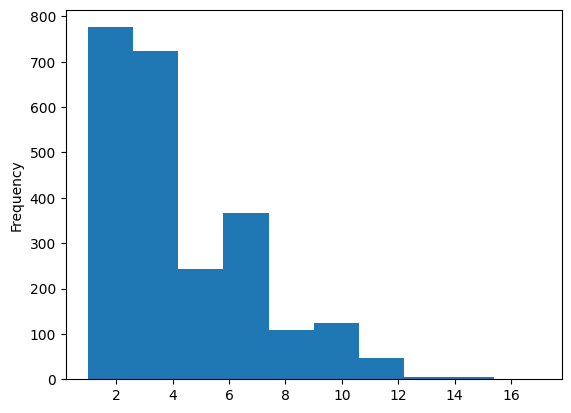

In [164]:
freq = orders.groupby("customer_id")["order_id"].count()
freq.plot(kind="hist")

In [165]:
# Observation:
# Most customers place only a small number of orders.
# The distribution is heavily right-skewed, meaning a few customers place significantly more orders than the majority.
# This indicates that repeat purchasing behavior is limited for most users.

# Churn-Risk Insight:
# Low purchase frequency is a strong indicator of weak engagement.
# Customers who place fewer orders are more likely to churn as they are not forming strong buying habits.
# High-frequency customers represent loyal users and are less likely to churn.

<Axes: ylabel='Frequency'>

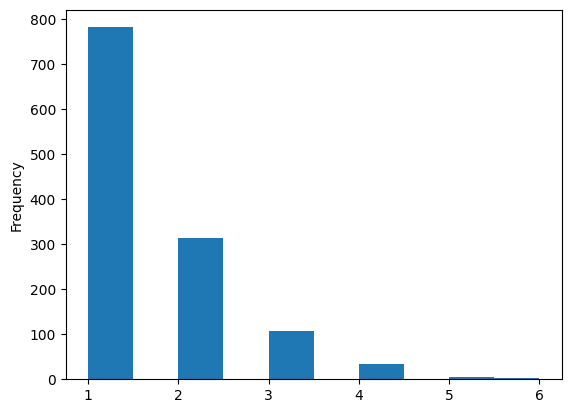

In [166]:
ticket_count = tickets.groupby("customer_id").size()
ticket_count.plot(kind="hist")

In [167]:
# Observation:
# Most customers have submitted very few or zero support tickets.
# A small subset of customers generates a high number of support tickets.
# The distribution is heavily right-skewed, showing concentrated support issues among a limited group.

# Churn-Risk Insight:
# Customers with higher ticket counts are more likely to be experiencing unresolved issues.
# Frequent support interactions often indicate dissatisfaction or product/service friction.
# This group represents a high churn-risk segment and should be prioritized for interventio

<Axes: >

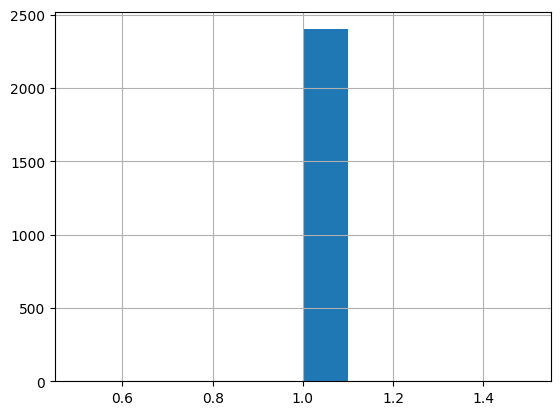

In [168]:
web["product_views_30d"].value_counts()
web.groupby("customer_id").size().hist()

In [169]:
# Observation:
# Product view activity is unevenly distributed across customers.
# A large number of customers have low product views in the last 30 days,
# while a smaller group shows significantly higher browsing activity.
# Web/app event counts per customer are also right-skewed, indicating that engagement is concentrated among a subset of users.

# Churn-Risk Insight:
# Customers with low product views and low interaction counts are likely less engaged with the platform.
# Low engagement is an early indicator of churn risk, as inactive users are less likely to convert or make repeat purchases.
# Highly active users, on the other hand, represent more loyal and engaged customer segments..

In [170]:
campaigns["last_campaign_received"].value_counts()

campaigns.groupby("customer_id")["last_campaign_received"].count()

customer_id
CUST00001    1
CUST00002    1
CUST00003    1
CUST00004    1
CUST00005    1
            ..
CUST02396    1
CUST02397    1
CUST02398    1
CUST02399    1
CUST02400    1
Name: last_campaign_received, Length: 2400, dtype: int64

In [171]:
# Observation:
# Campaign data shows uneven distribution of marketing exposure across customers.
# Some campaign types are more frequently sent than others, indicating targeted or repeated campaign strategies.
# At the customer level, most users receive a small number of campaigns,
# while a smaller subset is repeatedly targeted with marketing communications.

# Churn-Risk Insight:
# Customers with very low campaign exposure may indicate weak engagement or low targeting priority, increasing churn risk.
# However, customers receiving frequent campaigns may also become disengaged if communication becomes repetitive or irrelevant.
# Campaign frequency alone is not sufficient; effectiveness should be measured via engagement or response behavior.

<Axes: >

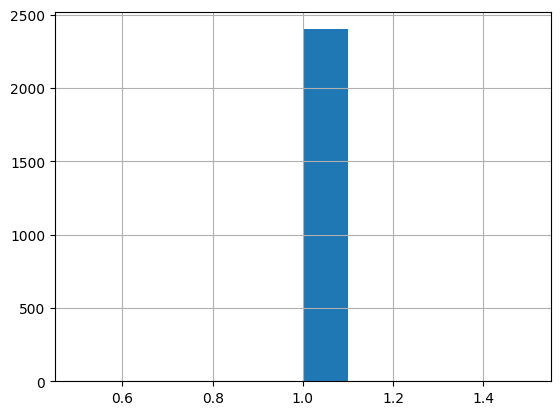

In [172]:
campaigns.groupby("customer_id")["last_campaign_received"].count().hist()

In [173]:
# Observation:
# Campaign exposure varies significantly across customers.
# Most customers receive a low to moderate number of campaigns,
# while a smaller subset is exposed to frequent marketing communications.
# The distribution suggests uneven targeting or engagement across the customer base.

# Churn-Risk Insight:
# Customers with low or no campaign interaction may represent disengaged users with higher churn risk.
# However, overly frequent campaign exposure could also lead to fatigue and reduced response rates.
# Campaign effectiveness should be evaluated based on engagement outcomes, not just exposure frequency.

In [174]:
churn["churn_next_60d"].value_counts(normalize=True)

churn_next_60d
0    0.530417
1    0.469583
Name: proportion, dtype: float64

In [175]:
# Observation:
# The churn distribution shows an imbalance between churned and non-churned customers.
# A majority of customers belong to the non-churned class, while a smaller fraction are labeled as churned.
# This indicates that churn is a minority outcome in the dataset.

# Churn-Risk Insight:
# Class imbalance is important for modeling because naive accuracy can be misleading.
# The minority churn class represents the high-risk group that the model must correctly identify.
# Metrics like recall, precision, and AUC are more appropriate than accuracy for churn prediction.

<Axes: xlabel='churn_next_60d'>

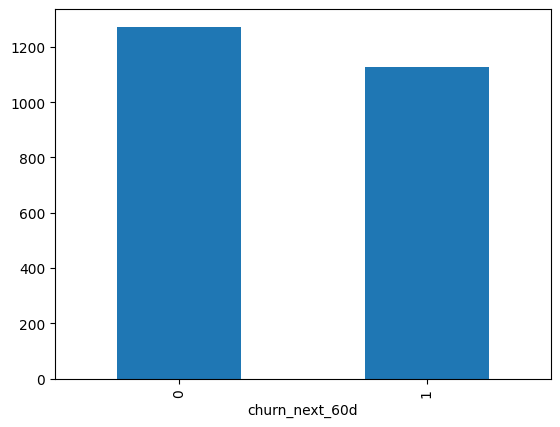

In [176]:
churn["churn_next_60d"].value_counts().plot(kind="bar")

In [177]:
# Observation:
# Dataset shows imbalance between churned and non-churned customers.
# Majority of customers are non-churned, indicating class imbalance.

# Churn Insight:
# Class imbalance must be considered in modeling, as accuracy alone may be misleading.
# Precision/recall or AUC should be preferred metrics.

### OBSERVED HYPOTHESIS :

**HYPOTHESIS 1: Low frequency → high churn**

**Customers who purchase only once or rarely show the highest churn. Engagement depth is a strong retention driver**

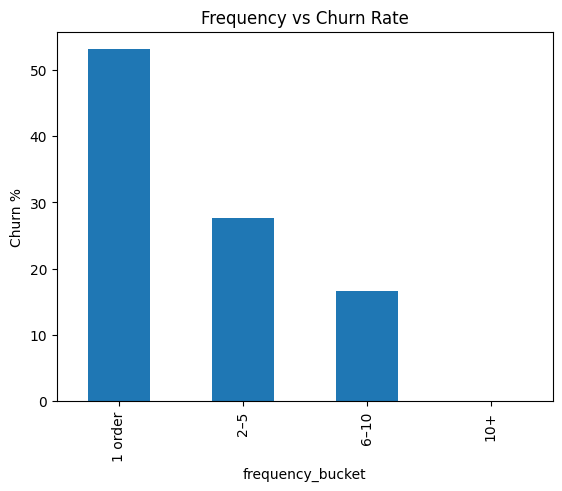

In [178]:
#Business Interpretation:
#Customers who rarely interact with the company are less engaged and more likely to switch to competitors. 
#Increasing repeat purchases through loyalty programs or personalized offers may reduce churn.

freq_df = rfm.copy()

freq_df["frequency_bucket"] = pd.cut(
    freq_df['frequency_180d'],
    bins=[0, 1, 5, 10, 1000],
    labels=["1 order", "2–5", "6–10", "10+"]
)

freq_analysis = freq_df.groupby("frequency_bucket")["churn_next_60d"].mean() * 100
import matplotlib.pyplot as plt

freq_analysis.plot(kind="bar")
plt.title("Frequency vs Churn Rate")
plt.ylabel("Churn %")
plt.show()

**HYPOTHESIS 2: High support tickets → churn**

**Frequent support interactions indicate unresolved problems, leading to dissatisfaction and churn.**

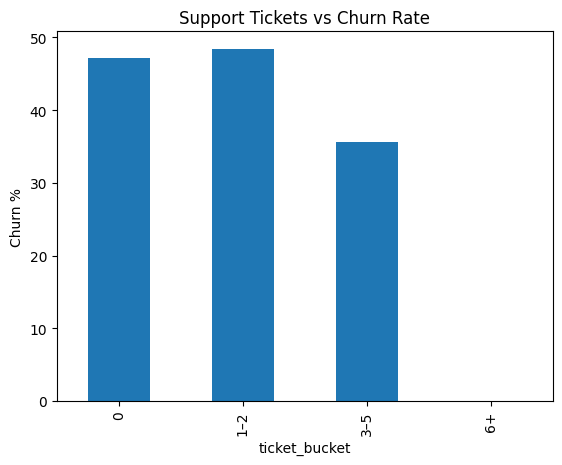

In [179]:
#Business Interpretation:
#Frequent complaints may indicate unresolved product or service issues. 
#Improving support quality and resolution times could help retain these customers.

ticket_counts = tickets.groupby("customer_id").size().reset_index()
ticket_counts.columns = ["customer_id", "ticket_count"]

df = rfm.merge(ticket_counts, on="customer_id", how="left")
df["ticket_count"] = df["ticket_count"].fillna(0)

df["ticket_bucket"] = pd.cut(
    df["ticket_count"],
    bins=[-1, 0, 2, 5, 100],
    labels=["0", "1–2", "3–5", "6+"]
)

ticket_analysis = df.groupby("ticket_bucket")["churn_next_60d"].mean() * 100   
ticket_analysis.plot(kind="bar")
plt.title("Support Tickets vs Churn Rate")
plt.ylabel("Churn %")
plt.show()

**Hypothesis 3: High refund rate increases churn**

**Refunds signal product mismatch or dissatisfaction, which strongly correlates with churn behavior.**

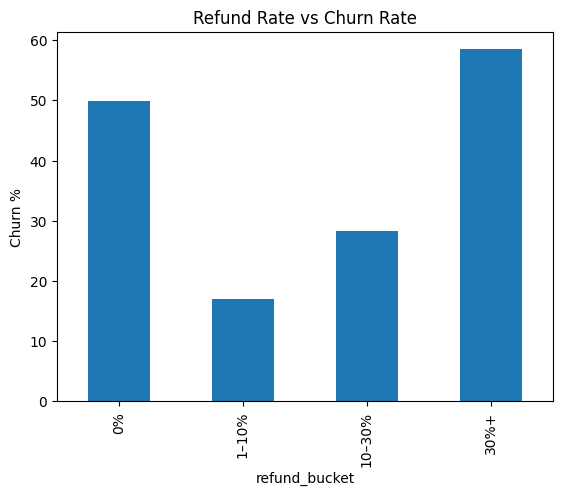

In [180]:
#Business Interpretation:
#Refund behavior suggests dissatisfaction with products, services, or customer expectations. 
#Investigating common refund reasons may help reduce customer attrition.

refund_rate = orders.groupby("customer_id")["returned"].mean().reset_index()
refund_rate.columns = ["customer_id", "refund_rate"]

df = rfm.merge(refund_rate, on="customer_id", how="left")
df["refund_rate"] = df["refund_rate"].fillna(0)

df["refund_bucket"] = pd.cut(
    df["refund_rate"],
    bins=[-0.01, 0, 0.1, 0.3, 1],
    labels=["0%", "1–10%", "10–30%", "30%+"]
)

refund_analysis = df.groupby("refund_bucket")["churn_next_60d"].mean() * 100
refund_analysis.plot(kind="bar")
plt.title("Refund Rate vs Churn Rate")
plt.ylabel("Churn %")
plt.show()

**Hypothesis 4:Customers with longer periods since their last purchase are at higher risk of churn.**

**A recency analysis was performed by segmenting customers based on the number of days since their most recent purchase.**

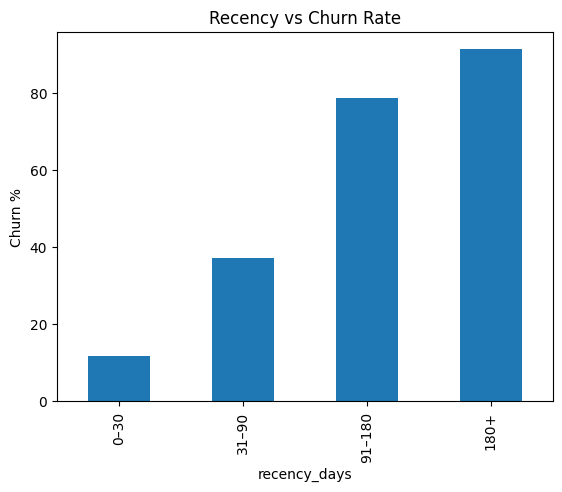

In [181]:
#Business implication: 
#Recency is a strong early warning signal. 
#Customers who have not purchased recently should be prioritized for retention campaigns before they become inactive permanently.

recency_bucket = pd.cut(
    rfm["recency_days"],
    bins=[0, 30, 90, 180, 10000],
    labels=["0–30", "31–90", "91–180", "180+"]
)

recency_analysis = rfm.groupby(recency_bucket)["churn_next_60d"].mean() * 100
recency_analysis.plot(kind="bar")
plt.title("Recency vs Churn Rate")
plt.ylabel("Churn %")
plt.show()

**Hypothesis 5 : High time gap between orders (inconsistent purchasing) increases churn risk**

**Customers who buy irregularly (long gaps between orders) are more likely to forget the product/service and churn.**

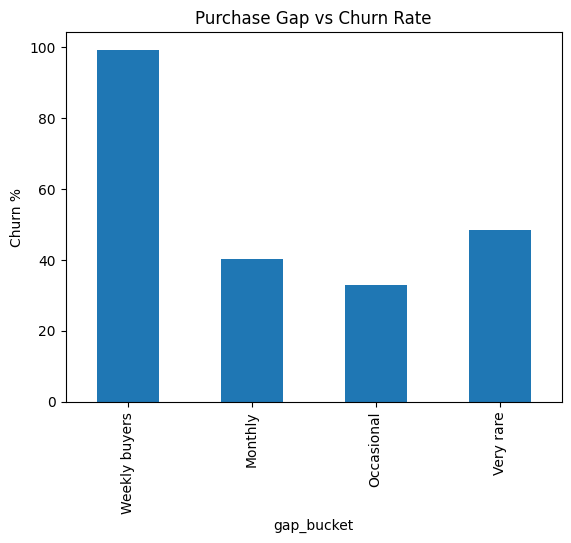

In [182]:
#Business implication: 
#Purchase frequency is a key indicator of customer engagement. 
#Customers whose purchase intervals begin to increase should be monitored and targeted with retention initiatives before they become inactive.

orders["order_date"] = pd.to_datetime(orders["order_date"])

# sort for correct gap calculation
orders_sorted = orders.sort_values(["customer_id", "order_date"])

# time difference between consecutive orders
orders_sorted["prev_order_date"] = orders_sorted.groupby("customer_id")["order_date"].shift(1)

orders_sorted["gap_days"] = (
    orders_sorted["order_date"] - orders_sorted["prev_order_date"]
).dt.days
gap_df = orders_sorted.groupby("customer_id")["gap_days"].mean().reset_index()
gap_df.columns = ["customer_id", "avg_gap_days"]
df = rfm.merge(gap_df, on="customer_id", how="left")
df["avg_gap_days"] = df["avg_gap_days"].fillna(0)
df["gap_bucket"] = pd.cut(
    df["avg_gap_days"],
    bins=[-1, 7, 30, 90, 10000],
    labels=["Weekly buyers", "Monthly", "Occasional", "Very rare"]
)
gap_analysis = df.groupby("gap_bucket")["churn_next_60d"].mean() * 100
gap_analysis
import matplotlib.pyplot as plt

gap_analysis.plot(kind="bar")
plt.title("Purchase Gap vs Churn Rate")
plt.ylabel("Churn %")
plt.show()